# Exploratory Data Analysis (EDA)

## What is EDA?
Exploratory Data Analysis is the process of **systematically examining a raw dataset** using summary statistics and visualisations before writing a single line of model code. It is where you learn the shape, quality, and structure of your data.

## Why is EDA mandatory before modelling?
| Reason | Impact if skipped |
|---|---|
| Reveals class imbalance | Model silently predicts the majority class and still shows 80% accuracy |
| Exposes missing values | NaN values silently break training without errors in some libraries |
| Shows outliers and noise | Outliers distort learned decision boundaries |
| Confirms target column validity | You may discover the label column is inconsistent or mislabelled |
| Guides feature engineering | You find correlations between columns before building features |
| Sets realistic performance expectations | Balanced data gives clean baselines; skewed data needs weighted loss |

## Six Questions This EDA Answers
1. **Shape & types** — How many rows and columns exist? What is each column's data type?
2. **Nulls** — Are there missing values? Do they affect our target columns (`Ticket Type`, `Ticket Priority`)?
3. **Class balance (type)** — Is `Ticket Type` balanced across all classes, or is one class dominating?
4. **Class balance (priority)** — Is `Ticket Priority` evenly distributed across Low / Medium / High / Critical?
5. **Text length** — How long are ticket descriptions on average, and does length vary by type?
6. **Type-Priority correlation** — Does a specific ticket type always carry a specific priority level?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_palette('Set2')

FIGURES_DIR = '../reports/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
DATA_PATH = '../data/raw/customer_support/customer_support_tickets.csv'
df = pd.read_csv(DATA_PATH)

print(f'Shape : {df.shape}')
print()
print('Data Types:')
print(df.dtypes)
print()
print('First 3 Rows:')
df.head(3)

Shape : (8469, 17)

Data Types:
Ticket ID                         int64
Customer Name                       str
Customer Email                      str
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Description                  str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Channel                      str
First Response Time                 str
Time to Resolution                  str
Customer Satisfaction Rating    float64
dtype: object

First 3 Rows:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [3]:
print('=== Numeric Column Statistics ===')
print(df.describe())
print()
print('=== Categorical / Text Column Statistics ===')
print(df.describe(include='object'))

=== Numeric Column Statistics ===
         Ticket ID  Customer Age  Customer Satisfaction Rating
count  8469.000000   8469.000000                   2769.000000
mean   4235.000000     44.026804                      2.991333
std    2444.934048     15.296112                      1.407016
min       1.000000     18.000000                      1.000000
25%    2118.000000     31.000000                      2.000000
50%    4235.000000     44.000000                      3.000000
75%    6352.000000     57.000000                      4.000000
max    8469.000000     70.000000                      5.000000

=== Categorical / Text Column Statistics ===
         Customer Name      Customer Email Customer Gender Product Purchased  \
count             8469                8469            8469              8469   
unique            8028                8320               3                42   
top     Michael Garcia  asmith@example.com            Male         Canon EOS   
freq                 5           

C:\Users\welcome\AppData\Local\Temp\ipykernel_15640\2677756652.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


=== Missing Value Table ===
                              Null Count  Null %
Customer Satisfaction Rating        5700   67.30
Resolution                          5700   67.30
Time to Resolution                  5700   67.30
First Response Time                 2819   33.29
Ticket ID                              0    0.00
Customer Name                          0    0.00
Customer Email                         0    0.00
Customer Age                           0    0.00
Customer Gender                        0    0.00
Ticket Subject                         0    0.00
Ticket Type                            0    0.00
Date of Purchase                       0    0.00
Product Purchased                      0    0.00
Ticket Priority                        0    0.00
Ticket Status                          0    0.00
Ticket Description                     0    0.00
Ticket Channel                         0    0.00


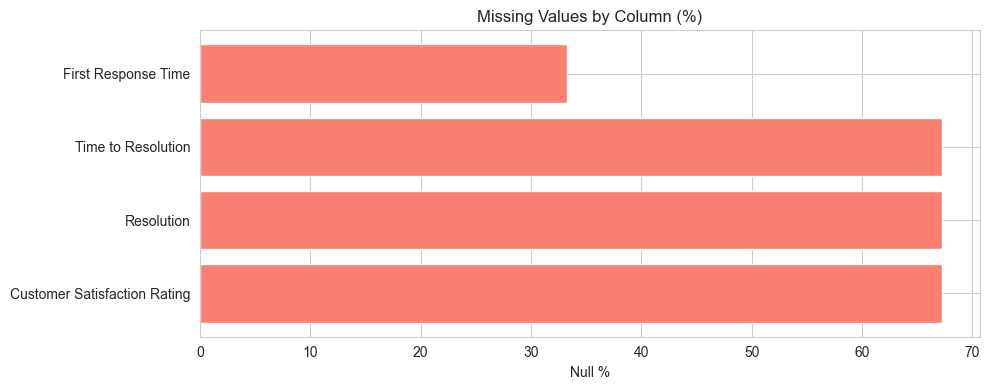

In [4]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

null_table = pd.DataFrame({
    'Null Count': null_counts,
    'Null %'    : null_pct
}).sort_values('Null %', ascending=False)

print('=== Missing Value Table ===')
print(null_table)

has_nulls = null_table[null_table['Null %'] > 0]
if not has_nulls.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(has_nulls) * 0.6)))
    ax.barh(has_nulls.index, has_nulls['Null %'], color='salmon')
    ax.set_xlabel('Null %')
    ax.set_title('Missing Values by Column (%)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + 'missing_values.png', dpi=150)
    plt.show()
else:
    print('No missing values found in any column.')

### Missing Value Observations

*(Fill in after running the cell above.)*

- **Columns with nulls:** list them here
- **Do nulls affect targets?**
  - `Ticket Type` null count: ?
  - `Ticket Priority` null count: ?
- **Action:** If nulls are in non-critical columns (e.g. `Resolution`, `Customer Name`) we can drop or impute in `03_data_cleaning.ipynb`. If nulls exist in `Ticket Description`, `Ticket Type`, or `Ticket Priority`, those rows must be dropped.

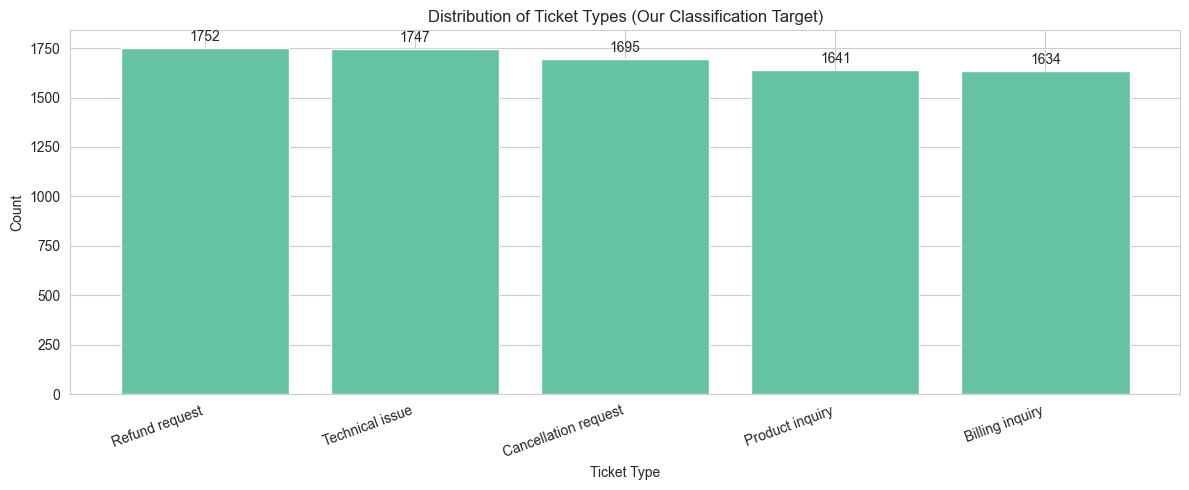

=== Class Percentage ===
Ticket Type
Refund request          20.69
Technical issue         20.63
Cancellation request    20.01
Product inquiry         19.38
Billing inquiry         19.29


In [5]:
type_counts = df['Ticket Type'].value_counts()
type_pct    = df['Ticket Type'].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
bars = ax.bar(type_counts.index, type_counts.values, edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('Distribution of Ticket Types (Our Classification Target)')
ax.set_xlabel('Ticket Type')
ax.set_ylabel('Count')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'ticket_type_distribution.png', dpi=150)
plt.show()

print('=== Class Percentage ===')
print(type_pct.round(2).to_string())

### Class Balance — Ticket Type

*(Fill in after running the cell above.)*

- If all classes are within **15–25% each** the distribution is balanced and standard cross-entropy loss is fine.
- If any single class **exceeds 40%** of all data we have class imbalance and will use `class_weight='balanced'` in Naive Bayes / SVM during Week 2 training.
- Note your observation here after seeing the chart.

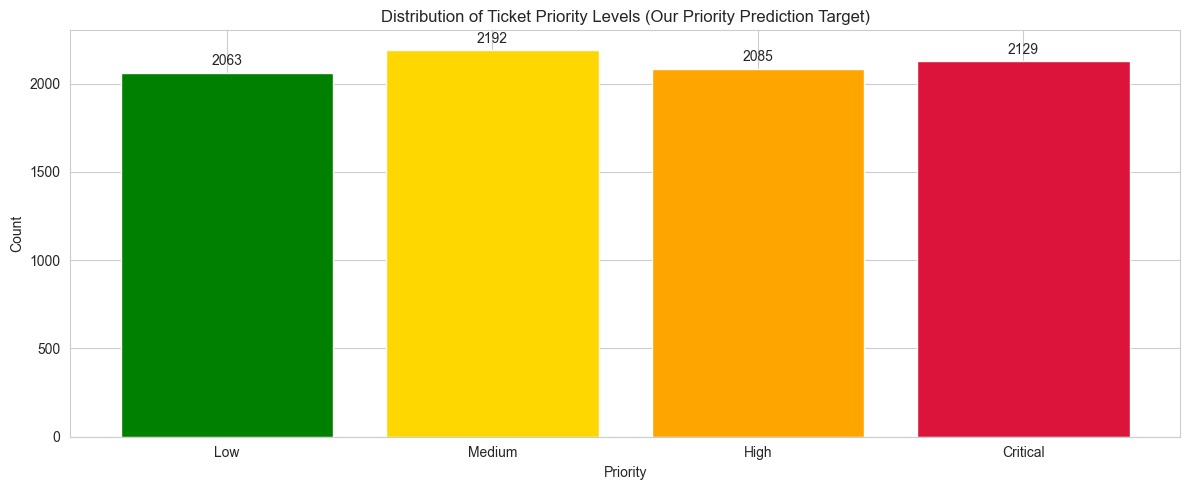

In [6]:
priority_order  = ['Low', 'Medium', 'High', 'Critical']
priority_colors = {'Low': 'green', 'Medium': 'gold', 'High': 'orange', 'Critical': 'crimson'}

present = [p for p in priority_order if p in df['Ticket Priority'].unique()]
priority_counts = df['Ticket Priority'].value_counts().reindex(present)
colors = [priority_colors[p] for p in priority_counts.index]

fig, ax = plt.subplots()
bars = ax.bar(priority_counts.index, priority_counts.values, color=colors, edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('Distribution of Ticket Priority Levels (Our Priority Prediction Target)')
ax.set_xlabel('Priority')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'ticket_priority_distribution.png', dpi=150)
plt.show()

### Class Balance — Ticket Priority

*(Fill in after running the cell above.)*

- Note whether all 4 levels (Low / Medium / High / Critical) are present.
- Note which priority is the most and least frequent.
- If severely imbalanced, apply `class_weight='balanced'` to the Random Forest / XGBoost priority predictor in Week 3.

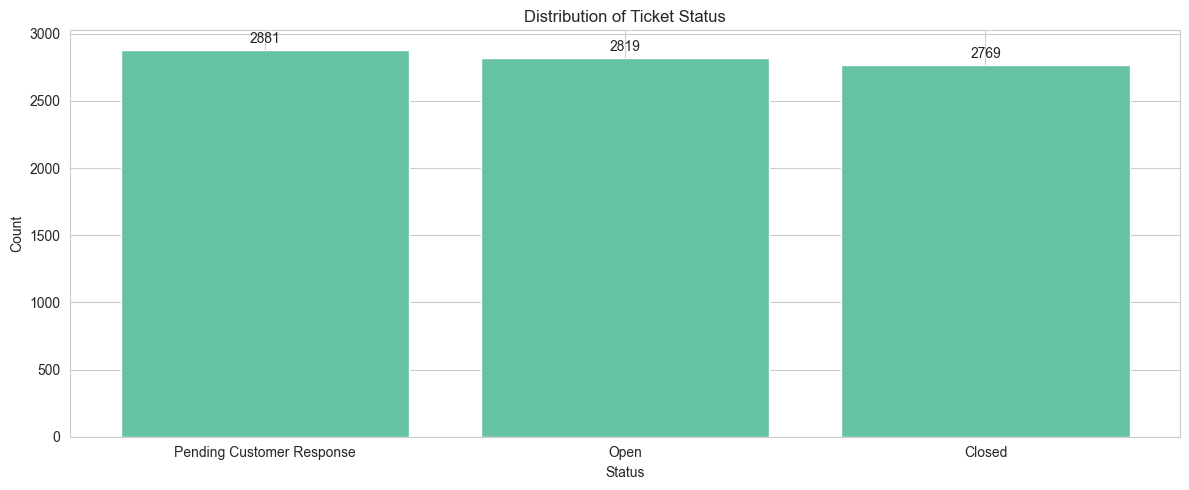

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64


In [7]:
status_counts = df['Ticket Status'].value_counts()

fig, ax = plt.subplots()
bars = ax.bar(status_counts.index, status_counts.values, edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('Distribution of Ticket Status')
ax.set_xlabel('Status')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'ticket_status_distribution.png', dpi=150)
plt.show()

print(status_counts)

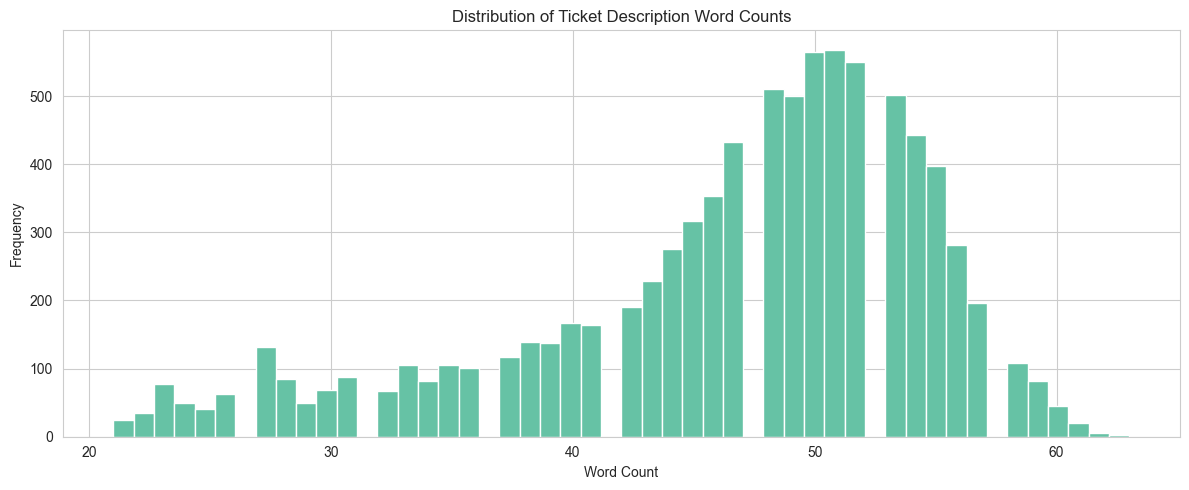

Min word count    : 21
Max word count    : 63
Mean word count   : 46.5
Median word count : 49.0


In [8]:
df['char_length'] = df['Ticket Description'].astype(str).apply(len)
df['word_count']  = df['Ticket Description'].astype(str).apply(lambda x: len(x.split()))

fig, ax = plt.subplots()
ax.hist(df['word_count'], bins=50, edgecolor='white')
ax.set_title('Distribution of Ticket Description Word Counts')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'word_count_distribution.png', dpi=150)
plt.show()

print(f'Min word count    : {df["word_count"].min()}')
print(f'Max word count    : {df["word_count"].max()}')
print(f'Mean word count   : {df["word_count"].mean():.1f}')
print(f'Median word count : {df["word_count"].median():.1f}')

### Text Length Note

The average word count determines our `max_length` setting when we move to BERT tokenisation later.

- BERT's hard limit is **512 tokens**. If the median word count is well below 200 we can safely set `max_length=128` or `max_length=256`, keeping training fast without losing coverage.
- Texts significantly shorter than 20 words are likely low-quality entries and will be flagged during cleaning.

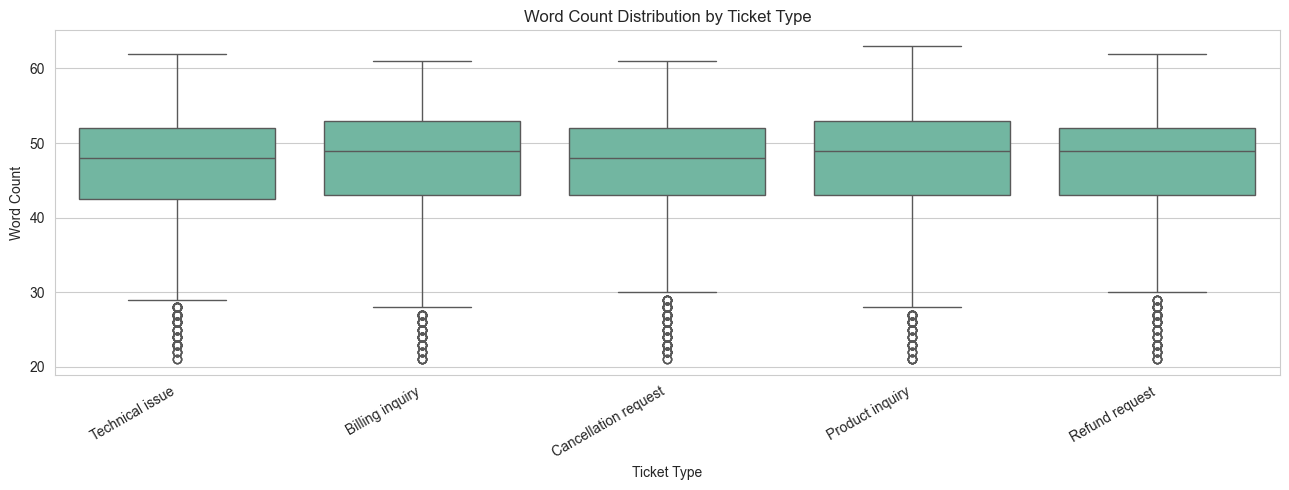

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x='Ticket Type', y='word_count', ax=ax)
ax.set_title('Word Count Distribution by Ticket Type')
ax.set_xlabel('Ticket Type')
ax.set_ylabel('Word Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'word_count_by_type.png', dpi=150)
plt.show()

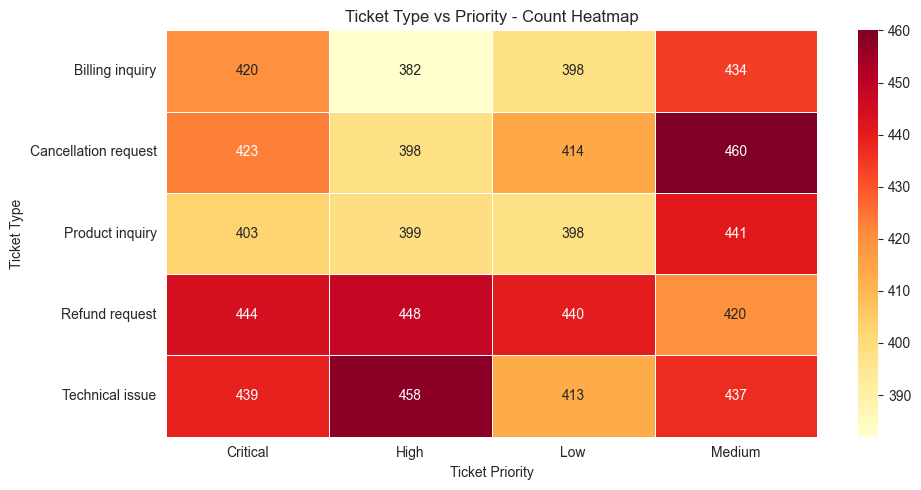

Ticket Priority       Critical  High  Low  Medium
Ticket Type                                      
Billing inquiry            420   382  398     434
Cancellation request       423   398  414     460
Product inquiry            403   399  398     441
Refund request             444   448  440     420
Technical issue            439   458  413     437


In [10]:
crosstab = pd.crosstab(df['Ticket Type'], df['Ticket Priority'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Ticket Type vs Priority - Count Heatmap')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'type_vs_priority_heatmap.png', dpi=150)
plt.show()

print(crosstab)

In [11]:
exact_dupes = df.duplicated().sum()
desc_dupes  = df['Ticket Description'].duplicated().sum()

print(f'Exact duplicate rows          : {exact_dupes}')
print(f'Duplicate Ticket Descriptions : {desc_dupes}')

if desc_dupes > 0:
    print()
    print('--- Sample Duplicate Descriptions ---')
    dup_mask = df['Ticket Description'].duplicated(keep=False)
    print(df[dup_mask][['Ticket Description', 'Ticket Type', 'Ticket Priority']].head(3).to_string())

Exact duplicate rows          : 0
Duplicate Ticket Descriptions : 392

--- Sample Duplicate Descriptions ---
                                                                                                                                                                                        Ticket Description      Ticket Type Ticket Priority
56                I'm having an issue with the {product_purchased}. Please assist. I've noticed that the issue occurs consistently when I use a specific feature or application on my {product_purchased}.  Technical issue          Medium
80   I'm having an issue with the {product_purchased}. Please assist. I'm unable to find the option to perform the desired action in the {product_purchased}. Could you please guide me through the steps?  Technical issue        Critical
105                                                I'm having an issue with the {product_purchased}. Please assist. I need assistance as soon as possible because it's affecting my wor

In [12]:
samples = df['Ticket Description'].sample(5, random_state=42)
for i, text in enumerate(samples, 1):
    print(f'--- Sample {i} ---')
    print(text)
    print()

--- Sample 1 ---
I'm having an issue with the {product_purchased}. Please assist. I'm using xda-developer for something different. If there are issues with the {product_purchased} it's likely you are not using the I've tried clearing the cache and data for the {product_purchased} app, but the issue persists.

--- Sample 2 ---
I'm having trouble connecting my {product_purchased} to my home Wi-Fi network. It doesn't detect any networks, although other devices are connecting fine. What can be done to resolve this issue? I will refer to this issue I've checked for any available software updates for my {product_purchased}, but there are none.

--- Sample 3 ---
I'm having an issue with the {product_purchased}. Please assist.

Please give credit to: @joeyclay I'm concerned about the security of my {product_purchased} and would like to ensure that my data is safe.

--- Sample 4 ---
I'm having an issue with the {product_purchased}. Please assist.

4. Check and compare product pricing

You will 

### Raw Text Observations  *(fill after running cell above)*

| Pattern to Check | Observed? | Action in 03_data_cleaning.ipynb |
|---|---|---|
| Special characters (`@`, `#`, `*`) | ? | Strip with regex |
| Email addresses embedded in text | ? | Remove with `re.sub` |
| Numbers / ticket IDs | ? | Remove or normalise |
| Very short entries (< 5 words) | ? | Flag and drop |
| Repetitive boilerplate phrases | ? | Evaluate before removing |

## EDA Summary

| Question | Finding |
|---|---|
| **Shape & types** | *(8,469 rows x 17 columns and types are Numeric, Datetime stored in the form of Object/String, Categorical, Free text)* |
| **Nulls** | *(Our two target columns are completly clean)* |
| **Ticket Type balance** | *(The result is almost balanced in a good way, where the largest class (Refund Request) is only 1.4% points above the smallest(Billing Inquiry.) A ratio of 1.07:1 means no imbalance at all* |
| **Ticket Priority balance** | *(Also nearly pefectly balanced. Range is only 129 tickets between highest and lowest, we don't need balancing at all)* |
| **Text length** | *(mean / median word count - 46/49 words, most of the tickets sit in the 44-54 word range which is an reasonably narrow band.)* |
| **Type-Priority correlation** | *(There is no meaningful correlation between ticket type and Priority.The distibution is essentially uniform across all 20 combinations. Which means essentially uniform across 20 combinations)* |
| **Duplicates** | *(There are 392 duplicates are unfilled template strings,the dataset was generated using templates which was substituted with an actual product name but wasn't for 392 rows, they appear across different ticket types and priorities, meaning they're moise that could misleads our classifier.)* |

### Figures Saved to `reports/figures/`
- `missing_values.png`
- `ticket_type_distribution.png`
- `ticket_priority_distribution.png`
- `ticket_status_distribution.png`
- `word_count_distribution.png`
- `word_count_by_type.png`
- `type_vs_priority_heatmap.png`

### Decisions Carried Forward
- **Class weighting:** *(needed / not needed - based on type/priority balance)*
- **BERT max_length:** *(set based on median word count)*
- **Rows to drop in cleaning:** *(nulls in targets, very short descriptions, duplicates)*

---
**Next:** `03_data_cleaning.ipynb` - drop nulls, remove duplicates, strip noise from text, save `data/processed/cleaned_tasks.csv`